# Dynamic Social Networks

## 1. Introduction

* **Static vs Dynamic Networks**:
  * Traditional networks were static, but real-world networks evolve over time (e.g. social ties form/break).
<br></br>

* **Dynamic Changes**:
  * Users join or leave.
  * Interaction strength fluctuates.
  * These changes affect processes like information or disease spread, centrality, and clustering.
<br></br>

* **Use Cases & Examples**:

  * Social media interactions and friendship evolution.
  * Wildlife tracking and epidemic simulations (e.g., crocodiles, herons).
  * Human systems under stress (e.g., COVID-19, Ukraine conflict).
    <br></br>

* **Social Media Impact**:

  * Hashtags, tags, and groups expand users' networks.
  * Algorithms can unintentionally promote:

    * Misinformation,
    * Racist or harmful ideologies,
    * Feedback loops of unhealthy content.
      <br></br>

* **Triadic Closure**:

  * A key mechanism in network evolution.
  * Based on the idea that **“friends of your friends are likely to become your friends.”**
  * Two forms:
    * **Connection-based**: Users are likely to connect if they share mutual friends.
    * **Metadata-based**: Users with shared interests are suggested to each other (e.g., football fans, hobby groups).
  * High **open triads** in a network signal strong potential for growth and new connections.


## 2. Import packages and initiate analysis

In [1]:
#create Figure 8-4
#import packages
import dynetx as dn
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
#create an empty graph
g = dn.DynGraph()

#add vertices and edges with time information added
g.add_interaction(u="D", v="E", t=0, e=2) # adding the edge ("D","E") at t=0 that vanishes at time e=2
g.add_interactions_from([("C", "F"), ("F", "E")], t=1) # adding some edges at time t=1
g.add_interactions_from([("B", "E"), ("A", "B")], t=2) # adding some edges at time t=2
g.add_interactions_from([("B", "C"),("C","D")], t=3) # adding some edges at time t=3
g.add_interaction(u="A", v="C", t=4) # adding some edges at time t=4

In [3]:
#create lists of edges at each time point
for i in range (5):
    g1 = g.time_slice(i)
    print ("snaptshot at t = ", i)
    print(g1.edges())

snaptshot at t =  0
[('D', 'E')]
snaptshot at t =  1
[('D', 'E'), ('E', 'F'), ('F', 'C')]
snaptshot at t =  2
[('E', 'B'), ('B', 'A')]
snaptshot at t =  3
[('D', 'C'), ('C', 'B')]
snaptshot at t =  4
[('C', 'A')]


snapshot at t =  0


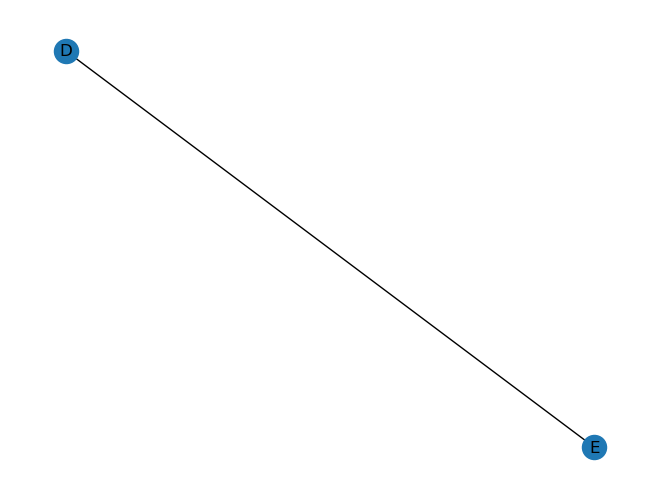

snapshot at t =  1


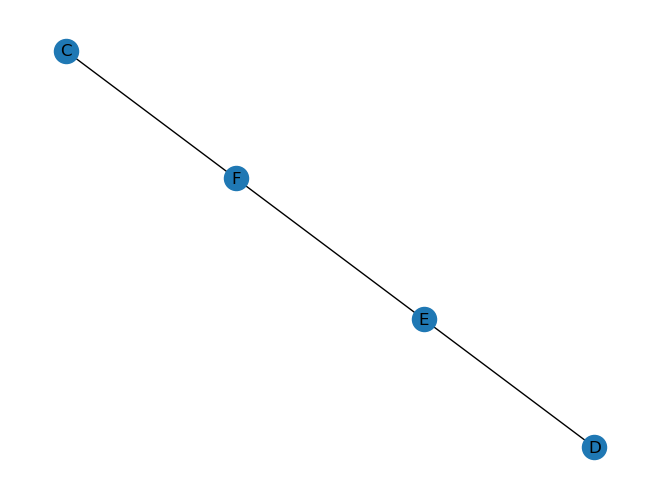

snapshot at t =  2


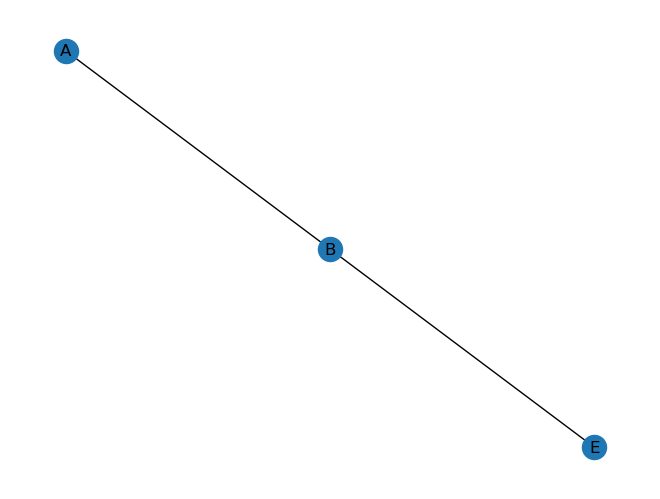

snapshot at t =  3


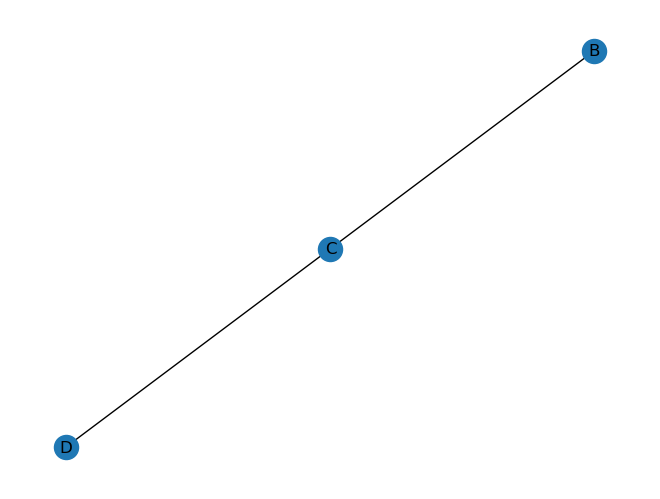

snapshot at t =  4


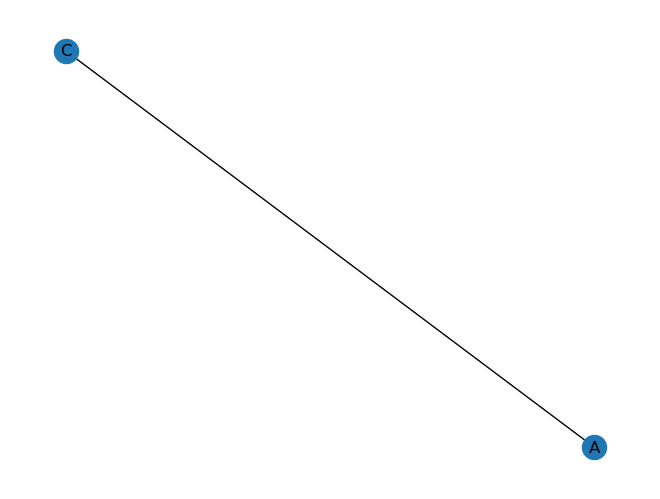

In [48]:
#create plots for each time point
for i in range (5):
    g1 = g.time_slice(i)
    nx.draw(g1,with_labels=True)
    print ("snapshot at t = ", i)
    plt.show()

In [46]:
#print interaction stream
for i in g.stream_interactions():
    print(i)

('D', 'E', '+', 0)
('C', 'F', '+', 1)
('F', 'E', '+', 1)
('D', 'E', '-', 2)
('B', 'E', '+', 2)
('A', 'B', '+', 2)
('B', 'C', '+', 3)
('C', 'D', '+', 3)
('A', 'C', '+', 4)
